# 5장 실습 — 피드포워드 SNN 만들기

**Spiking Neural Networks 쿡북 with Python** · 5장 실습 노트북

LIF 뉴런을 층으로 쌓아 **완전연결 피드포워드 SNN**을 만들고, 입력 스파이크가 층을 타고 흐르는 과정을 시간에 따라 순전파한다.

### 학습 목표
- 가중 입력에 대한 단일 LIF 뉴런 반응을 본다.
- `nn.Linear`와 `snn.Leaky`로 2층 SNN을 구성한다.
- 시간 전개 순전파로 은닉층·출력층 스파이크를 기록·시각화한다.

> 이 책의 실습 코드는 가독성을 위해 `if`문과 `try/except` 예외처리를 사용하지 않는다.

## 1. 설치와 임포트

In [1]:
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import spikegen
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0)

## 2. 가중 입력에 대한 단일 뉴런 반응

한 뉴런이 받는 입력은 앞 층 신호에 가중치를 곱한 값이다. 작은 가중 계단 입력을 `snn.Leaky`에 주면 막전위가 차오르다 규칙적으로 발화한다.

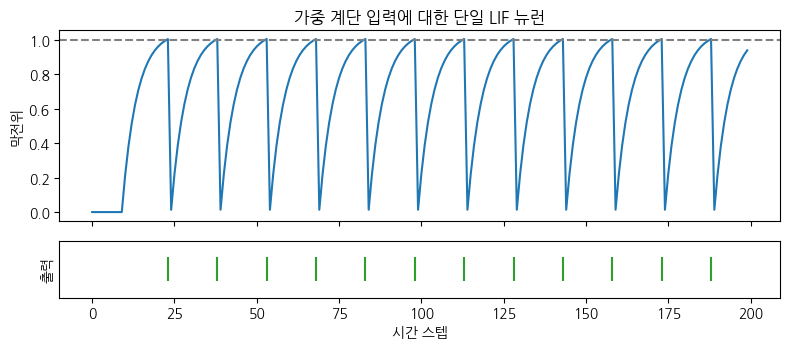

In [2]:
lif = snn.Leaky(beta=0.8)
num_steps = 200
w = 0.21                                              # 가중치
cur_in = torch.cat([torch.zeros(10, 1), torch.ones(190, 1) * w])
mem = lif.init_leaky()
mem_rec, spk_rec = [], []

for step in range(num_steps):
    spk, mem = lif(cur_in[step], mem)
    mem_rec.append(mem)
    spk_rec.append(spk)

mem_rec = torch.stack(mem_rec).squeeze().detach().numpy()
spk_rec = torch.stack(spk_rec).squeeze().detach().numpy()

import numpy as np
fig, (a0, a1) = plt.subplots(
    2, 1, 
    figsize=(8, 3.6), 
    sharex=True,
    gridspec_kw={'height_ratios': [2, 0.6]}
)
a0.plot(mem_rec, color='tab:blue'); a0.axhline(1.0, color='gray', linestyle='--')
a0.set_ylabel('막전위'); a0.set_title('가중 계단 입력에 대한 단일 LIF 뉴런')
spk_t = np.where(spk_rec > 0)[0]
a1.scatter(spk_t, [0] * len(spk_t), marker='|', s=300, color='tab:green')
a1.set_yticks([]); a1.set_ylabel('출력'); a1.set_xlabel('시간 스텝')
plt.tight_layout(); plt.show()

## 3. 2층 완전연결 SNN 정의

`nn.Linear`(가중치)와 `snn.Leaky`(뉴런)를 번갈아 둔다. 입력 784 → 은닉 1000 → 출력 10 구조다. 각 뉴런의 막전위 상태는 `init_leaky()`로 초기화한다.

In [3]:
num_inputs, num_hidden, num_outputs = 784, 1000, 10
beta = 0.99

fc1 = nn.Linear(num_inputs, num_hidden)   # 입력 → 은닉 가중치
lif1 = snn.Leaky(beta=beta)               # 은닉 LIF 층
fc2 = nn.Linear(num_hidden, num_outputs)  # 은닉 → 출력 가중치
lif2 = snn.Leaky(beta=beta)               # 출력 LIF 층

print('네트워크 구성: 784 → 1000(LIF) → 10(LIF)')

네트워크 구성: 784 → 1000(LIF) → 10(LIF)


## 4. 시간 전개 순전파

임의의 입력 스파이크 열(200스텝, 784개 입력)을 만들어 네트워크에 흘린다. 매 스텝마다 `fc → lif`를 거치며 은닉·출력 스파이크를 기록한다. `for` 루프가 시간의 흐름이다.

In [4]:
num_steps = 200
# 임의의 입력 스파이크 열 생성 (200스텝, 배치1, 784입력)
spk_in = spikegen.rate_conv(torch.rand((num_steps, 784))).unsqueeze(1)

mem1 = lif1.init_leaky()
mem2 = lif2.init_leaky()
spk1_rec, spk2_rec, mem2_rec = [], [], []

for step in range(num_steps):
    cur1 = fc1(spk_in[step])       # 은닉층 시냅스후 전류
    spk1, mem1 = lif1(cur1, mem1)  # 은닉 LIF 반응
    cur2 = fc2(spk1)               # 출력층 시냅스후 전류
    spk2, mem2 = lif2(cur2, mem2)  # 출력 LIF 반응
    spk1_rec.append(spk1)
    spk2_rec.append(spk2)
    mem2_rec.append(mem2)

spk1_rec = torch.stack(spk1_rec).squeeze(1).detach()
spk2_rec = torch.stack(spk2_rec).squeeze(1).detach()
print('은닉 스파이크 형태:', tuple(spk1_rec.shape), '| 출력 스파이크 형태:', tuple(spk2_rec.shape))

은닉 스파이크 형태: (200, 1000) | 출력 스파이크 형태: (200, 10)


## 5. 은닉층·출력층 스파이크 시각화

은닉층 일부 뉴런과 출력층 10개 뉴런의 스파이크를 래스터로 본다. 학습 전이므로 패턴은 무작위에 가깝지만, 정보가 **희소한 스파이크**로 층을 타고 흐른다는 구조를 확인할 수 있다.

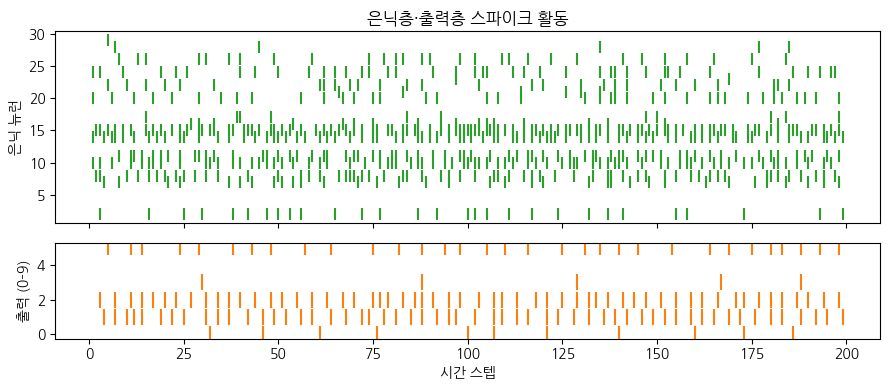

In [5]:
import numpy as np
fig, (a0, a1) = plt.subplots(
    2, 1, 
    figsize=(9, 4), 
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1]}
)
# 은닉 뉴런 30개만 표시
for n in range(30):
    t = np.where(spk1_rec[:, n].numpy() > 0)[0]
    a0.scatter(t, [n] * len(t), marker='|', s=80, color='tab:green')
a0.set_ylabel('은닉 뉴런'); a0.set_title('은닉층·출력층 스파이크 활동')
for n in range(10):
    t = np.where(spk2_rec[:, n].numpy() > 0)[0]
    a1.scatter(t, [n] * len(t), marker='|', s=120, color='tab:orange')
a1.set_ylabel('출력 (0–9)'); a1.set_xlabel('시간 스텝')
plt.tight_layout(); plt.show()

## 정리

- 한 층의 입력은 앞 층 스파이크에 가중치를 곱한 시냅스후 전류다.
- `nn.Linear`와 `snn.Leaky`를 번갈아 쌓아 피드포워드 SNN을 만든다.
- 같은 입력을 시간 스텝 반복해 순전파하며 각 층 스파이크를 기록한다.

다음 6장에서는 시냅스 전류라는 상태를 하나 더 둔 2차 뉴런으로 들어간다.